# Stability Analysis - MyBESS Parameter Sweep

Start from `MyBESS`, change one parameter, initialize each case, linearize it, and compare the modes.


In [1]:
include("../FullWorkflow/scripts/dictionaries.jl")
include("../FullWorkflow/scripts/helpers.jl")
include("../ParametricStudies/scripts/parametric_study_helpers.jl")
include("../ParametricStudies/scripts/single_model_initialization.jl")

using .FullWorkflowHelpers
using .ModelInitialization
using OMJulia, LinearAlgebra, DataFrames


## User Configuration


In [2]:
BASE_MODEL = "MyBESS"
BASE_MODEL_FILE = abspath("models/MyBESS.mo")

DYNAWO_PKG_PATH = "/home/clarafercas/Model_library/dynawo/dynawo/sources/Models/Modelica/Dynawo/package.mo"
MODELICA_PKG_PATH = "/home/clarafercas/dynawo/OpenModelica/lib/omlibrary/Modelica/package.mo"

SWEEP_COMPONENT = "BESS"
SWEEP_PARAMETER = "Kpg"
SWEEP_VALUES = [1.0, 2.0, 3.0, 5.0, 7.0, 10.0]

LINEARIZATION_TIME = "2.0"
MODE_TOL = 1e-8

INIT_MODEL_BY_COMPONENT = Dict{String, String}()

# Leave empty to disable slack-specific handling.
SLACK_COMPONENT = ""

OUTPUT_DIR = abspath("outputs/MyBESS_Kpg_stability_sweep");


## Prepare OpenModelica Session


In [3]:
BUILD_OUTPUT_DIR = joinpath(OUTPUT_DIR, "omc-build")

isfile(BASE_MODEL_FILE) || error("Base model file not found: $BASE_MODEL_FILE")
isfile(DYNAWO_PKG_PATH) || error("Dynawo package not found: $DYNAWO_PKG_PATH")
isfile(MODELICA_PKG_PATH) || error("Modelica package not found: $MODELICA_PKG_PATH")

rm(OUTPUT_DIR; recursive = true, force = true)
mkpath(BUILD_OUTPUT_DIR)

StudyOMC = OMJulia.OMCSession()
load_modelica_file!(
    StudyOMC,
    BASE_MODEL_FILE,
    MODELICA_PKG_PATH,
    DYNAWO_PKG_PATH,
)
omc_call(StudyOMC, "checkModel($BASE_MODEL)", parsed = false)
OMJulia.quit(StudyOMC)

println("OpenModelica session checked successfully.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.QzVS4Lt86Y"


OpenModelica session checked successfully.


## Run the Parameter Sweep


In [4]:
A_matrices = Dict{Float64, Matrix{Float64}}()
linear_states_by_case = Dict{Float64, Vector{String}}()
linearization_sizes = NamedTuple[]

for value in SWEEP_VALUES
    label = case_label(value)
    parameter_name = replace(SWEEP_PARAMETER, "." => "_")
    case_model = join([BASE_MODEL, SWEEP_COMPONENT, parameter_name, label], "_")
    case_build_dir = joinpath(BUILD_OUTPUT_DIR, case_model)
    mkpath(case_build_dir)

    StudyOMC = OMJulia.OMCSession()

    try
        load_modelica_file!(
            StudyOMC,
            BASE_MODEL_FILE,
            MODELICA_PKG_PATH,
            DYNAWO_PKG_PATH,
        )

        omc_call(
            StudyOMC,
            "setParameterValue($(BASE_MODEL), $(SWEEP_COMPONENT).$(SWEEP_PARAMETER), $(string(value)))",
            parsed = false,
        )

        initialized_case = initialize_loaded_model(
            StudyOMC;
            source_model = BASE_MODEL,
            case_name = case_model,
            output_dir = OUTPUT_DIR,
            modelica_package_path = MODELICA_PKG_PATH,
            dynawo_package_path = DYNAWO_PKG_PATH,
            init_model_by_component = INIT_MODEL_BY_COMPONENT,
            slack_component = SLACK_COMPONENT,
        )

        linearized_model = initialized_case.initialized_model

        ModelicaSystem(
            StudyOMC,
            nothing,
            linearized_model,
            [MODELICA_PKG_PATH, DYNAWO_PKG_PATH];
            customBuildDirectory = case_build_dir,
        )

        setLinearizationOptions(
            StudyOMC,
            [
                "startTime=0.0",
                "stopTime=$LINEARIZATION_TIME",
                "stepSize=0.001",
                "tolerance=1e-6",
            ],
        )

        matrices = linearize(StudyOMC; lintime = LINEARIZATION_TIME, verbose = false)

        A_matrices[value] = Matrix{Float64}(Float64.(matrices[1]))
        linear_states_by_case[value] = String.(getLinearStates(StudyOMC))

        if value == first(SWEEP_VALUES)
            push!(linearization_sizes, (
                A = join(string.(size(matrices[1])), "x"),
                B = join(string.(size(matrices[2])), "x"),
                C = join(string.(size(matrices[3])), "x"),
                D = join(string.(size(matrices[4])), "x"),
            ))
        end
    finally
        OMJulia.quit(StudyOMC)
    end

    println("Finished $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
end

linear_states = linear_states_by_case[first(SWEEP_VALUES)]

for value in SWEEP_VALUES
    if linear_states_by_case[value] != linear_states
        error("Linear state order changed for $SWEEP_COMPONENT.$SWEEP_PARAMETER = $value")
    end
end

println("Linearization sweep finished.")


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.BoC7jBlG6R"
[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.DfriAbJtz7"
  Julia 1.12 has introduced more strict world age semantics for global bindings.
  !!! This code may malfunction under Revise.
  !!! This code will error in future versions of Julia.
Hint: Add an appropriate `invokelatest` around the access to this binding.
To make this warning an error, and hence obtain a stack trace, use `julia --depwarn=error`.


Finished BESS.Kpg = 1.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.pMgnRFyCok"
[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.2wYqnlwuEE"


Finished BESS.Kpg = 2.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.fCQ9eDAiPl"
[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.Tk9kEHnlQw"


...

Finished BESS.Kpg = 5.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.4nuumYe5bh"
[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.0mOC2BLFae"


Finished BESS.Kpg = 7.0


[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.R8KSYgKFvV"
[ Info: Path to zmq file="/tmp/openmodelica.clarafercas.port.julia.sXhdrtSuYL"


Finished BESS.Kpg = 10.0
Linearization sweep finished.


## Linearization Summary


In [5]:
sizes = linearization_sizes[1]

linearization_summary = DataFrame([(
    n_states = length(linear_states),
    size_A = sizes.A,
    size_B = sizes.B,
    size_C = sizes.C,
    size_D = sizes.D,
)])

display(linearization_summary)


Row,n_states,size_A,size_B,size_C,size_D
,Int64,String,String,String,String
1,20,20x20,20x0,0x20,0x0


## Analyze Modes


In [6]:
mode_rows = NamedTuple[]
summary_rows = NamedTuple[]

for value in SWEEP_VALUES
    A = A_matrices[value]

    eigenvalues = eigvals(A)
    real_parts = real.(eigenvalues)

    for (mode_index, lambda) in enumerate(eigenvalues)
        real_part = real(lambda)
        imag_part = imag(lambda)

        stability = if real_part > MODE_TOL
            "unstable"
        elseif real_part < -MODE_TOL
            "stable"
        else
            "marginal"
        end

        push!(mode_rows, (
            parameter_value = value,
            mode = mode_index,
            real_part = real_part,
            imag_part = imag_part,
            stability = stability,
        ))
    end

    push!(summary_rows, (
        parameter_value = value,
        max_real_part = maximum(real_parts),
        unstable_modes = count(real_parts .> MODE_TOL),
        marginal_modes = count(abs.(real_parts) .<= MODE_TOL),
        stable_modes = count(real_parts .< -MODE_TOL),
    ))
end

mode_df = sort(DataFrame(mode_rows), [:parameter_value, :mode])
stability_summary = sort(DataFrame(summary_rows), :parameter_value)

println("Mode analysis finished.")


Mode analysis finished.


## Check Unstable Modes


In [7]:
unstable_modes = Int[]

for mode in sort(unique(mode_df.mode))
    rows_for_mode = mode_df[mode_df.mode .== mode, :]

    if any(rows_for_mode.stability .== "unstable")
        push!(unstable_modes, mode)
    end
end

unstable_mode_table = DataFrame(mode = unstable_modes)

for value in SWEEP_VALUES
    column_name = Symbol("$SWEEP_PARAMETER=$(value)")
    stability_values = String[]

    for mode in unstable_modes
        rows_for_mode = mode_df[(mode_df.mode .== mode) .& (mode_df.parameter_value .== value), :]
        push!(stability_values, rows_for_mode.stability[1])
    end

    unstable_mode_table[!, column_name] = stability_values
end

unstable_mode_rows = in.(mode_df.mode, Ref(unstable_modes))
unstable_mode_df = sort(mode_df[unstable_mode_rows, :], [:mode, :parameter_value])

println("Unstable-mode check finished.")


Unstable-mode check finished.


## Modes


In [8]:
println("Stability summary")
display(stability_summary)

println("Modes that become unstable")
display(unstable_mode_table)


Stability summary


Row,parameter_value,max_real_part,unstable_modes,marginal_modes,stable_modes
,Float64,Float64,Int64,Int64,Int64
1,1.0,0.0,0,3,17
2,2.0,0.0,0,3,17
3,3.0,0.0,0,3,17
4,5.0,0.0,0,3,17
5,7.0,0.380722,2,3,15
6,10.0,3.15468,2,3,15


Modes that become unstable


Row,mode,Kpg=1.0,Kpg=2.0,Kpg=3.0,Kpg=5.0,Kpg=7.0,Kpg=10.0
,Int64,String,String,String,String,String,String
1,19,marginal,marginal,marginal,marginal,unstable,unstable
2,20,marginal,marginal,marginal,marginal,unstable,unstable


## Mode Plots


WebIO._IJuliaInit()

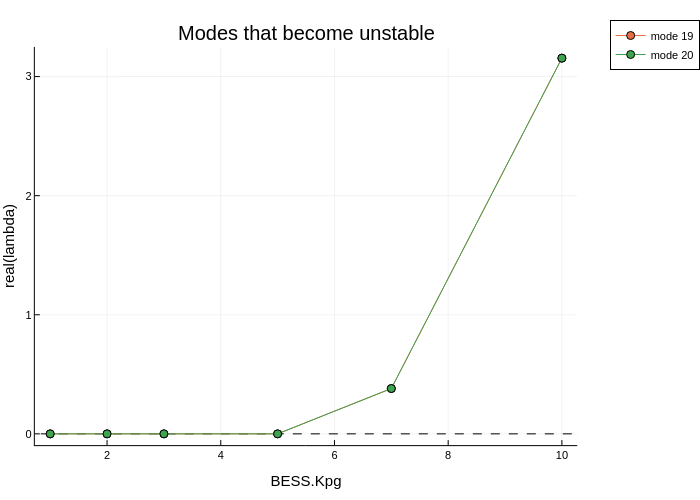

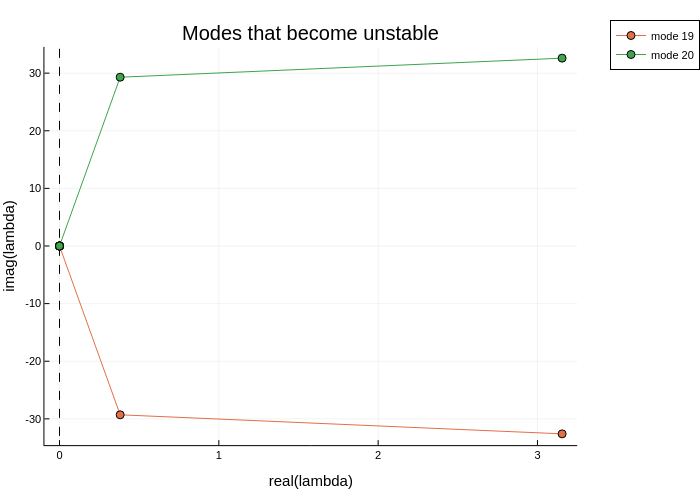

In [9]:
using Plots

plotlyjs()

if isempty(unstable_modes)
    println("No modes become unstable for these sweep values.")
else
    real_part_plot = plot(
        xlabel = "$SWEEP_COMPONENT.$SWEEP_PARAMETER",
        ylabel = "real(lambda)",
        title = "Modes that become unstable",
        legend = :outertopright,
    )
    hline!(real_part_plot, [0.0], line = (:dash, :black), label = "")

    for mode in unstable_modes
        mode_data = unstable_mode_df[unstable_mode_df.mode .== mode, :]
        plot!(
            real_part_plot,
            mode_data.parameter_value,
            mode_data.real_part,
            marker = :circle,
            label = "mode $mode",
        )
    end

    display(real_part_plot)

    complex_plane_plot = plot(
        xlabel = "real(lambda)",
        ylabel = "imag(lambda)",
        title = "Modes that become unstable",
        legend = :outertopright,
    )
    vline!(complex_plane_plot, [0.0], line = (:dash, :black), label = "")

    for mode in unstable_modes
        mode_data = unstable_mode_df[unstable_mode_df.mode .== mode, :]
        plot!(
            complex_plane_plot,
            mode_data.real_part,
            mode_data.imag_part,
            marker = :circle,
            label = "mode $mode",
        )
    end

    display(complex_plane_plot)
end
